ROC AUC: 0.6733
Accuracy: 0.6009
Recall(most important): 0.6875


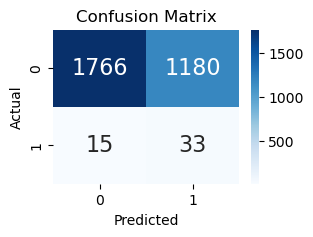

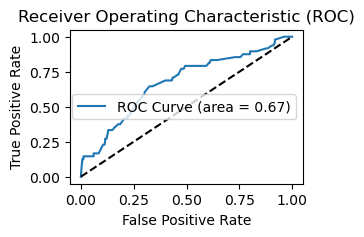

ROC AUC: 0.6538
Accuracy: 0.6827
Recall(most important): 0.5417


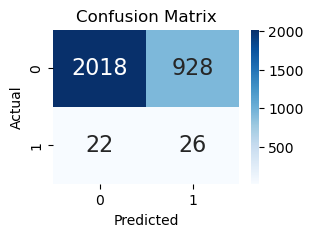

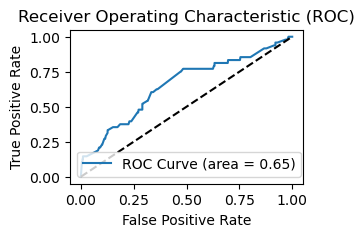

ROC AUC: 0.6736
Accuracy: 0.5755
Recall(most important): 0.7500


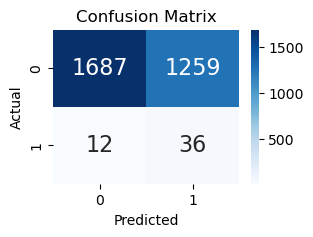

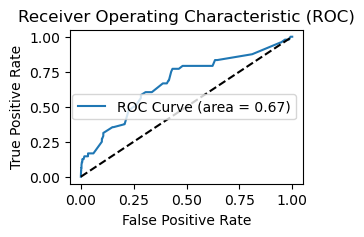

ROC AUC: 0.6485
Accuracy: 0.6770
Recall(most important): 0.5833


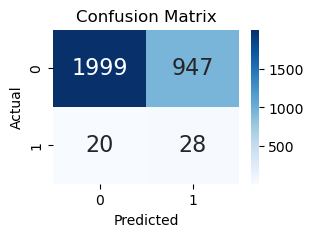

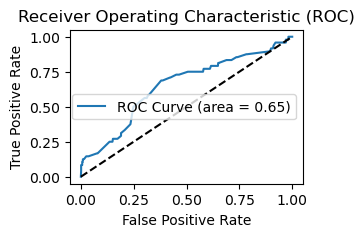

ROC AUC: 0.6776
Accuracy: 0.6620
Recall(most important): 0.6458


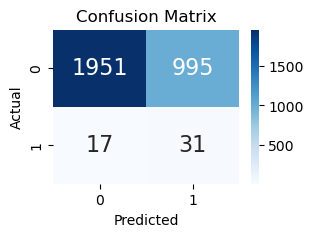

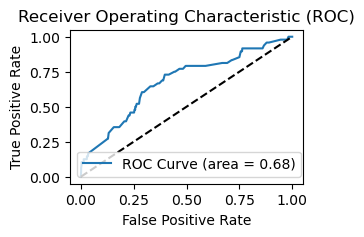

(0.6008684034736139, 0.6875, 0.6732787395338312)
(0.6826987307949232, 0.5416666666666666, 0.653760749038244)
(0.5754843019372078, 0.75, 0.6736075752432676)
(0.6770207080828323, 0.5833333333333334, 0.6484887700837294)
(0.6619906479625919, 0.6458333333333334, 0.6776349287169043)
Mean Accuracy: 0.640
Mean Recall: 0.64
Mean ROC AUC: 0.665


In [19]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
# from xgboost import XGBClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def normalize2(row, mean_df, std_df, athlete_id):
    '''
    Normalize the data using z-score normalization.
    '''
    mu = mean_df.loc[athlete_id]
    su = std_df.loc[athlete_id]
    z = (row - mu)/su
    return z

def getMeanStd(data):
    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getBalancedSubset(X_train, samplesPerClass):
    '''
    Create a balanced subset of the data by sampling from each athlete's data.
    '''
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()
    
    stats = pd.DataFrame(X_train[['Athlete ID','injury']].groupby(['Athlete ID','injury']).size().reset_index(name='counts'))
    stats = pd.DataFrame(stats[['Athlete ID']].groupby(['Athlete ID']).size().reset_index(name='counts'))
    stats.drop(stats[stats['counts'] < 2].index, inplace=True)
    athleteList = stats['Athlete ID'].unique()

    samplesPerAthlete = int(np.floor(samplesPerClass) / len(athleteList))

    for athlete in athleteList:
        if unhealthySet.empty:
            unhealthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete, replace=True)
        else:
            unhealthySet = pd.concat([unhealthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete,replace=True)], ignore_index=True)
        if healthySet.empty:
            healthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete, replace=True)
        else:
            healthySet = pd.concat([healthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete,replace=True)], ignore_index=True)


    balancedSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return balancedSet


def preparedata(df,test_athletes):
    '''
    Prepare the data for training and testing.
    This includes normalization, creating a balanced subset of the data, and splitting into training and testing sets.
    '''
    X_test_original = df[df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy for normalization
    X_train_original = df[~df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy

    X_train_means, X_train_std = getMeanStd(X_train_original)
    X_test_means, X_test_std = getMeanStd(X_test_original)
    X_train_balanced = getBalancedSubset(X_train_original.copy(), 2048)
    
    # Set target variable for testing and training
    y_train = X_train_balanced['injury']
    y_test = X_test_original['injury']

    # Apply normalization to the balanced training data
    X_train_norm = X_train_balanced.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
    X_train_norm = X_train_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

    # Apply normalization to the test data using the testing statistics
    # Note this is a source of data leakage! but the alternative is not feasible
    X_test_norm = X_test_original.apply(lambda x: normalize2(x, X_test_means, X_test_std, x['Athlete ID']), axis=1)
    X_test_norm = X_test_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


    return y_train, y_test, X_train_norm, X_test_norm

def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''
    # model = XGBClassifier()
    # model = GaussianNB()

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=500, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)

def eval(model, y_true, X, y_pred, **params):
    '''
    Produce key evaluation metrics without visualisations.
    '''
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, Recall(most important): {recall:.3f}")
   
    return (accuracy,recall,roc_auc)

def run_exps(df,test_set, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = preparedata(df, test_set)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model
    
    
def main():
    '''
    Main function to run the experiments.
    '''

    # Load, clean, and split the data
    dfday = pd.read_csv('../data/combodf.csv')
    dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)
    athletes = sorted(list(dfday['Athlete ID'].unique()))
    test_athletes = athletes[len(athletes) - 10:]

    # run experiments to determine the best model
    best_model = run_exps(dfday, test_athletes, n = 5, C=0.01, penalty='elasticnet', solver='saga', l1_ratio=0.5)
   
    # Save the model to a file
    # with open('../models/logistic_model.pkl', 'wb') as f:
    #    pickle.dump(best_model, f)

    
    # Uncomment the following lines to run additional experiments with different hyperparameters
    '''
    print("-" * 50)  # Separator for better readability
    C_values = [0.001, 0.01, 0.1, 1, 10]
    l1_ratio_values = [0.2, 0.5, 0.8]
    for C in C_values:
        for l1_ratio in l1_ratio_values:
            print(f"Running experiments with C={C}, l1_ratio={l1_ratio}, penalty='elasticnet', solver='saga', class_weight='balanced'")
            run_exps(dfday, test_athletes, n = 3, C=C, penalty='elasticnet', solver='saga', l1_ratio=l1_ratio)
            print("-" * 50)  # Separator for better readability
   '''
   
main()

### next attempt with no normalisation
Change the preparedata function to exclude normalisation and rerun

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5824
Accuracy: 0.4937
Recall(most important): 0.6458


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


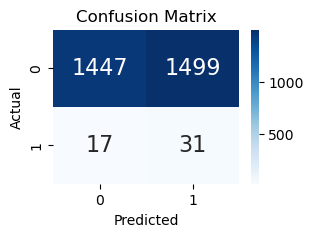

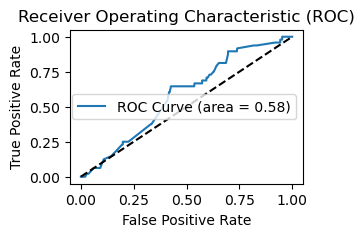

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5730
Accuracy: 0.4840
Recall(most important): 0.6667


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


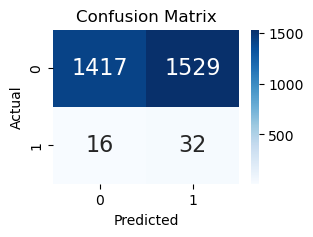

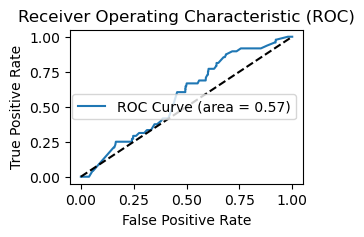

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5924
Accuracy: 0.4923
Recall(most important): 0.6667


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


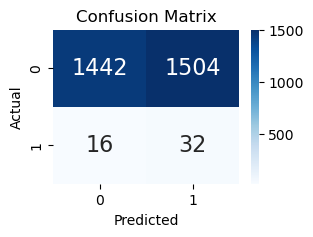

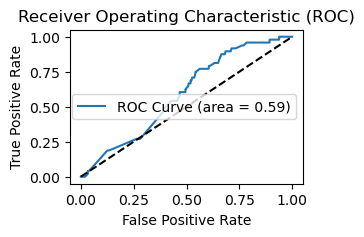

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5965
Accuracy: 0.5351
Recall(most important): 0.6250


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


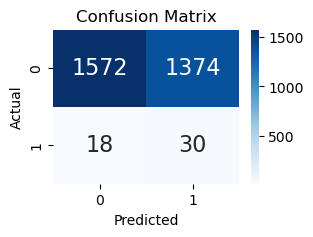

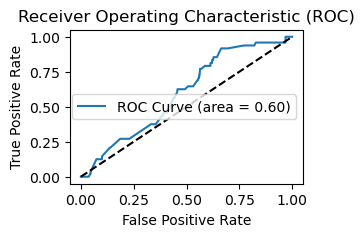

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5789
Accuracy: 0.5217
Recall(most important): 0.6458


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


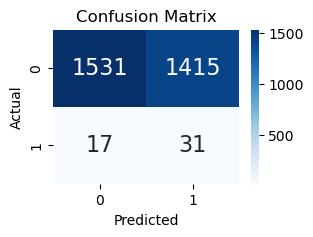

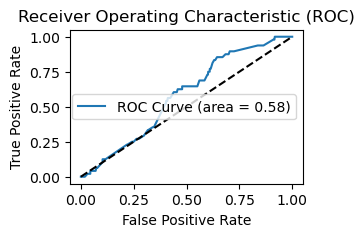

(0.49365397461589844, 0.6458333333333334, 0.5823998642226749)
(0.48396793587174347, 0.6666666666666666, 0.5729979916270649)
(0.4923179692718771, 0.6666666666666666, 0.5923533322018556)
(0.5350701402805611, 0.625, 0.5964938334464811)
(0.5217100868403474, 0.6458333333333334, 0.5789205702647657)
Mean Accuracy: 0.505
Mean Recall: 0.65
Mean ROC AUC: 0.585


In [3]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
# from xgboost import XGBClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# def norm ...

def getMeanStd(data):
    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getBalancedSubset(X_train, samplesPerClass):
    '''
    Create a balanced subset of the data by sampling from each athlete's data.
    '''
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()
    
    stats = pd.DataFrame(X_train[['Athlete ID','injury']].groupby(['Athlete ID','injury']).size().reset_index(name='counts'))
    stats = pd.DataFrame(stats[['Athlete ID']].groupby(['Athlete ID']).size().reset_index(name='counts'))
    stats.drop(stats[stats['counts'] < 2].index, inplace=True)
    athleteList = stats['Athlete ID'].unique()

    samplesPerAthlete = int(np.floor(samplesPerClass) / len(athleteList))

    for athlete in athleteList:
        if unhealthySet.empty:
            unhealthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete, replace=True)
        else:
            unhealthySet = pd.concat([unhealthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete,replace=True)], ignore_index=True)
        if healthySet.empty:
            healthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete, replace=True)
        else:
            healthySet = pd.concat([healthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete,replace=True)], ignore_index=True)


    balancedSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return balancedSet


def preparedata(df,test_athletes):
    '''
    Prepare the data for training and testing.
    This includes normalization, creating a balanced subset of the data, and splitting into training and testing sets.
    '''
    X_test_original = df[df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy for normalization
    X_train_original = df[~df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy

    X_train_means, X_train_std = getMeanStd(X_train_original)
    X_test_means, X_test_std = getMeanStd(X_test_original)
    X_train_balanced = getBalancedSubset(X_train_original.copy(), 2048)
    
    # Set target variable for testing and training
    y_train = X_train_balanced['injury']
    y_test = X_test_original['injury']

    # Apply normalization to the balanced training data
    # X_train_norm = X_train_balanced.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
    X_train = X_train_balanced.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

    # Apply normalization to the test data using the testing statistics
    # Note this is a source of data leakage! but the alternative is not feasible
    #X_test_norm = X_test_original.apply(lambda x: normalize2(x, X_test_means, X_test_std, x['Athlete ID']), axis=1)
    X_test = X_test_original.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


    return y_train, y_test, X_train, X_test

def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''
    # model = XGBClassifier()
    # model = GaussianNB()

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=500, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)

def eval(model, y_true, X, y_pred, **params):
    '''
    Produce key evaluation metrics without visualisations.
    '''
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, Recall(most important): {recall:.3f}")
   
    return (accuracy,recall,roc_auc)

def run_exps(df,test_set, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = preparedata(df, test_set)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model
    
    
def main():
    '''
    Main function to run the experiments.
    '''

    # Load, clean, and split the data
    dfday = pd.read_csv('../data/combodf.csv')
    dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)
    athletes = sorted(list(dfday['Athlete ID'].unique()))
    test_athletes = athletes[len(athletes) - 10:]

    # run experiments to determine the best model
    best_model = run_exps(dfday, test_athletes, n = 5, C=0.01, penalty='elasticnet', solver='saga', l1_ratio=0.5)
   
    # Save the model to a file
    # with open('../models/logistic_model.pkl', 'wb') as f:
    #    pickle.dump(best_model, f)

    
    # Uncomment the following lines to run additional experiments with different hyperparameters
    '''
    print("-" * 50)  # Separator for better readability
    C_values = [0.001, 0.01, 0.1, 1, 10]
    l1_ratio_values = [0.2, 0.5, 0.8]
    for C in C_values:
        for l1_ratio in l1_ratio_values:
            print(f"Running experiments with C={C}, l1_ratio={l1_ratio}, penalty='elasticnet', solver='saga', class_weight='balanced'")
            run_exps(dfday, test_athletes, n = 3, C=C, penalty='elasticnet', solver='saga', l1_ratio=l1_ratio)
            print("-" * 50)  # Separator for better readability
   '''
   
main()

(0.5621242484969939, 0.7916666666666666, 0.6857674247567322)
(0.6723446893787575, 0.6458333333333334, 0.6836423681828467)
(0.5935203740814963, 0.6875, 0.6649199479520252)
(0.5260521042084169, 0.7083333333333334, 0.6763408010862186)
(0.5895123580494323, 0.7291666666666666, 0.6964457456438109)
Mean Accuracy: 0.589
Mean Recall: 0.71
Mean ROC AUC: 0.681

- with no normalisation

(0.49365397461589844, 0.6458333333333334, 0.5823998642226749)
(0.48396793587174347, 0.6666666666666666, 0.5729979916270649)
(0.4923179692718771, 0.6666666666666666, 0.5923533322018556)
(0.5350701402805611, 0.625, 0.5964938334464811)
(0.5217100868403474, 0.6458333333333334, 0.5789205702647657)
Mean Accuracy: 0.505
Mean Recall: 0.65
Mean ROC AUC: 0.585

a definite drop in accuracy. volume per athlete seems to matter significantly more than total volume. 

what if I don't subset by athlete and instead subset the whole thing? I mean they're normalised right?

so without subsetting by athlete it seems I don't lose too much. but here I am still splitting the data the same way I think. how would that go for me?

(0.5591182364729459, 0.6666666666666666, 0.673540393754243)
(0.5487641950567802, 0.7291666666666666, 0.6910570830504639)
(0.6205744822979292, 0.6875, 0.6954521667798144)
(0.5177020708082832, 0.7083333333333334, 0.691933978275628)
(0.5895123580494323, 0.7291666666666666, 0.7041751527494908)
Mean Accuracy: 0.567
Mean Recall: 0.70
Mean ROC AUC: 0.691


ROC AUC: 0.6735
Accuracy: 0.5591
Recall(most important): 0.6667


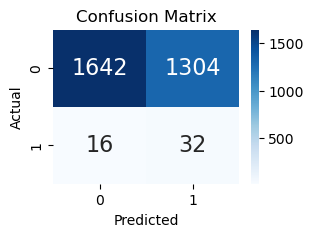

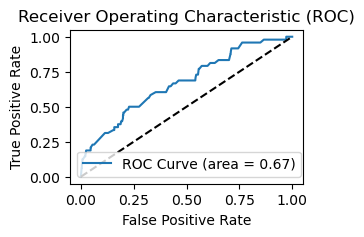

ROC AUC: 0.6911
Accuracy: 0.5488
Recall(most important): 0.7292


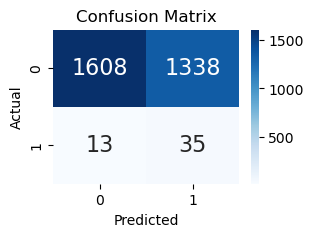

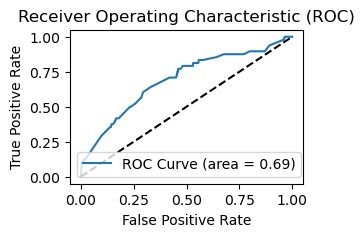

ROC AUC: 0.6955
Accuracy: 0.6206
Recall(most important): 0.6875


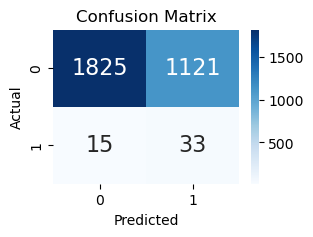

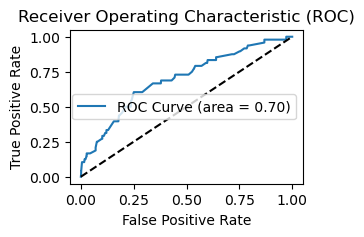

ROC AUC: 0.6919
Accuracy: 0.5177
Recall(most important): 0.7083


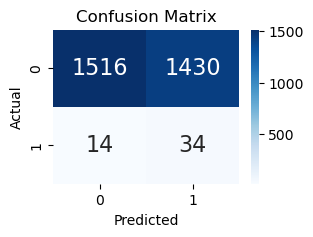

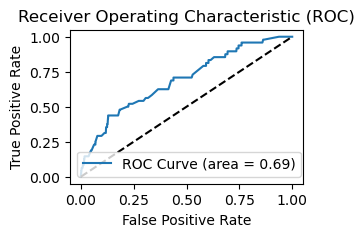

ROC AUC: 0.7042
Accuracy: 0.5895
Recall(most important): 0.7292


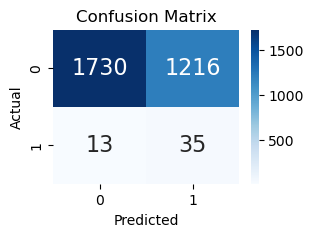

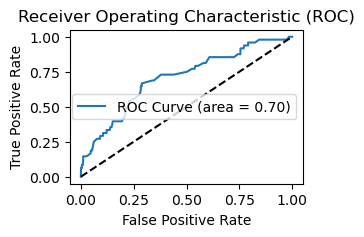

(0.5591182364729459, 0.6666666666666666, 0.673540393754243)
(0.5487641950567802, 0.7291666666666666, 0.6910570830504639)
(0.6205744822979292, 0.6875, 0.6954521667798144)
(0.5177020708082832, 0.7083333333333334, 0.691933978275628)
(0.5895123580494323, 0.7291666666666666, 0.7041751527494908)
Mean Accuracy: 0.567
Mean Recall: 0.70
Mean ROC AUC: 0.691


In [6]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
# from xgboost import XGBClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def normalize2(row, mean_df, std_df, athlete_id):
    '''
    Normalize the data using z-score normalization.
    '''
    mu = mean_df.loc[athlete_id]
    su = std_df.loc[athlete_id]
    z = (row - mu)/su
    return z

def getMeanStd(data):
    ''' 
    Calculate the mean and standard deviation for each athlete's data.
    This is used for normalization.
    '''

    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getregsubset(X_train, samplesPerClass):
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()

    unhealthySet = X_train[X_train['injury'] == 0].sample(samplesPerClass, replace=True)
    healthySet = X_train[X_train['injury'] == 1].sample(samplesPerClass, replace=True)


    regSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return regSet


def preparedata(df,test_athletes):
    '''
    Prepare the data for training and testing.
    This includes normalization, creating a balanced subset of the data, and splitting into training and testing sets.
    '''
    X_test_original = df[df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy for normalization
    X_train_original = df[~df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy

    X_train_means, X_train_std = getMeanStd(X_train_original)
    X_test_means, X_test_std = getMeanStd(X_test_original)
    X_train_balanced = getregsubset(X_train_original.copy(), 2048)
    
    # Set target variable for testing and training
    y_train = X_train_balanced['injury']
    y_test = X_test_original['injury']

    # Apply normalization to the balanced training data
    X_train_norm = X_train_balanced.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
    X_train_norm = X_train_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

    # Apply normalization to the test data using the testing statistics
    # Note this is a source of data leakage! but the alternative is not feasible
    X_test_norm = X_test_original.apply(lambda x: normalize2(x, X_test_means, X_test_std, x['Athlete ID']), axis=1)
    X_test_norm = X_test_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


    return y_train, y_test, X_train_norm, X_test_norm

def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''
    # model = XGBClassifier()
    # model = GaussianNB()

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=500, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)

def eval(model, y_true, X, y_pred, **params):
    '''
    Produce key evaluation metrics without visualisations.
    '''
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, Recall(most important): {recall:.3f}")
   
    return (accuracy,recall,roc_auc)

def run_exps(df,test_set, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = preparedata(df, test_set)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model
    
    
def main():
    '''
    Main function to run the experiments.
    '''

    # Load, clean, and split the data
    dfday = pd.read_csv('../data/combodf.csv')
    dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)
    athletes = sorted(list(dfday['Athlete ID'].unique()))
    test_athletes = athletes[len(athletes) - 10:]

    # run experiments to determine the best model
    best_model = run_exps(dfday, test_athletes, n = 5, C=0.01, penalty='elasticnet', solver='saga', l1_ratio=0.5)
   
    # Save the model to a file
    # with open('../models/logistic_model.pkl', 'wb') as f:
    #    pickle.dump(best_model, f)

    
    # Uncomment the following lines to run additional experiments with different hyperparameters
    '''
    print("-" * 50)  # Separator for better readability
    C_values = [0.001, 0.01, 0.1, 1, 10]
    l1_ratio_values = [0.2, 0.5, 0.8]
    for C in C_values:
        for l1_ratio in l1_ratio_values:
            print(f"Running experiments with C={C}, l1_ratio={l1_ratio}, penalty='elasticnet', solver='saga', class_weight='balanced'")
            run_exps(dfday, test_athletes, n = 3, C=C, penalty='elasticnet', solver='saga', l1_ratio=l1_ratio)
            print("-" * 50)  # Separator for better readability
   '''
   
main()

### added splitting at random v=rather than by athlete

In [26]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def normalize2(row, mean_df, std_df, athlete_id):
    '''
    Normalize the data using z-score normalization.
    '''
    mu = mean_df.loc[athlete_id]
    su = std_df.loc[athlete_id]
    z = (row - mu)/su
    return z

def getMeanStd(data):
    ''' 
    Calculate the mean and standard deviation for each athlete's data.
    This is used for normalization.
    '''

    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getregsubset(X_train, samplesPerClass):
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()

    unhealthySet = X_train[X_train['injury'] == 0].sample(samplesPerClass, replace=True)
    healthySet = X_train[X_train['injury'] == 1].sample(samplesPerClass, replace=True)


    regSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return regSet


def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=500, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)


def run_exps(df, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = prepare_split(df)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model


  

In [ ]:
def prepare_split(df):
    '''
    subsets then splits the data for training and testing.

    '''
 
    # Create balanced subset
    df_means, df_std = getMeanStd(df)  
    df_balanced = getregsubset(df, 2048)
    df_cop= df_balanced.copy()
    
    # Normalize only the feature columns
    X_norm = df_balanced.apply(
        lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), axis=1)
    y = df_cop['injury']
    X_norm= X_norm.drop(columns=['injury','Athlete ID','date'], errors='ignore')
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_norm, y,
        test_size= 0.3,
        random_state= 24,
        stratify=y  # This ensures same ratio of injured/non-injured in both sets
    )

    return y_train, y_test, X_train, X_test

In [3]:

dfday = pd.read_csv('../data/combodf.csv')
dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)

ROC AUC: 0.6702
Accuracy: 0.6290
Recall(most important): 0.5407


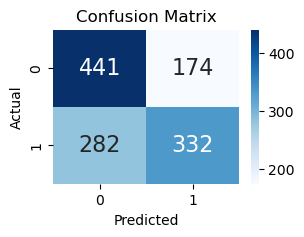

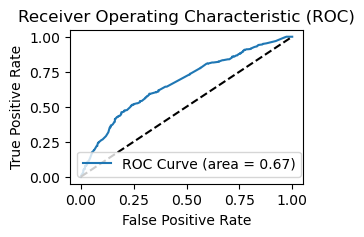

ROC AUC: 0.6850
Accuracy: 0.6216
Recall(most important): 0.5684


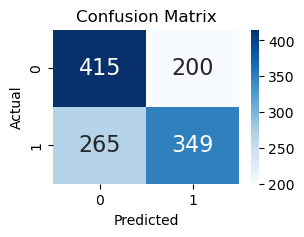

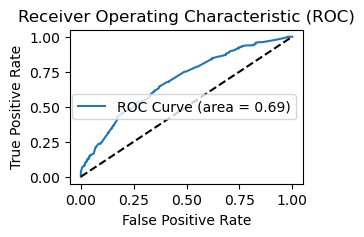

ROC AUC: 0.6647
Accuracy: 0.6282
Recall(most important): 0.5277


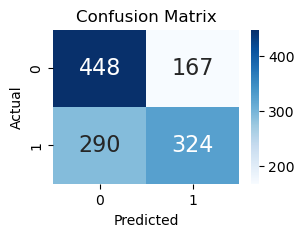

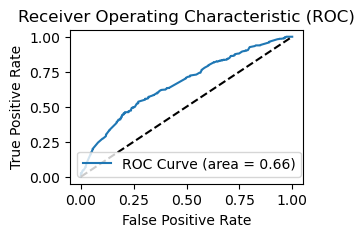

ROC AUC: 0.6756
Accuracy: 0.6314
Recall(most important): 0.5293


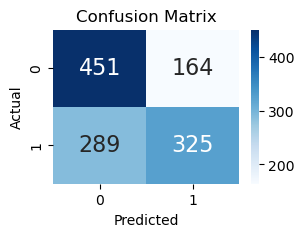

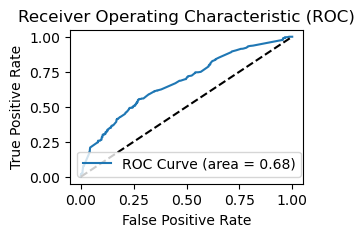

ROC AUC: 0.6480
Accuracy: 0.6119
Recall(most important): 0.5619


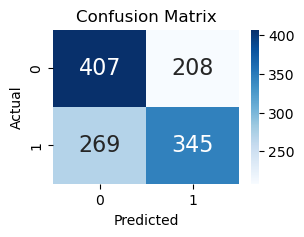

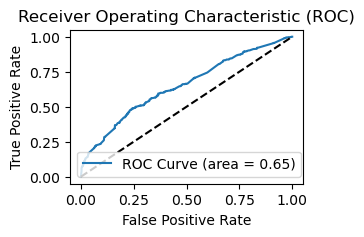

(0.628966639544345, 0.5407166123778502, 0.6702232462064035)
(0.6216436126932465, 0.5684039087947883, 0.6850454172294166)
(0.628152969894223, 0.5276872964169381, 0.6647188898599083)
(0.6314076484947111, 0.5293159609120521, 0.6755819496305712)
(0.611879576891782, 0.5618892508143323, 0.6479688037922724)
Mean Accuracy: 0.624
Mean Recall: 0.55
Mean ROC AUC: 0.669


In [11]:
best_model = run_exps(dfday, n = 5, C=0.01, penalty='elasticnet', solver='saga', l1_ratio=0.5)


(0.5621242484969939, 0.7916666666666666, 0.6857674247567322)
(0.6723446893787575, 0.6458333333333334, 0.6836423681828467)
(0.5935203740814963, 0.6875, 0.6649199479520252)
(0.5260521042084169, 0.7083333333333334, 0.6763408010862186)
(0.5895123580494323, 0.7291666666666666, 0.6964457456438109)
Mean Accuracy: 0.589
Mean Recall: 0.71
Mean ROC AUC: 0.681

- with no normalisation

(0.49365397461589844, 0.6458333333333334, 0.5823998642226749)
(0.48396793587174347, 0.6666666666666666, 0.5729979916270649)
(0.4923179692718771, 0.6666666666666666, 0.5923533322018556)
(0.5350701402805611, 0.625, 0.5964938334464811)
(0.5217100868403474, 0.6458333333333334, 0.5789205702647657)
Mean Accuracy: 0.505
Mean Recall: 0.65
Mean ROC AUC: 0.585

a definite drop in accuracy. volume per athlete seems to matter significantly more than total volume. 

what if I don't subset by athlete and instead subset the whole thing? I mean they're normalised right?

so without subsetting by athlete it seems I don't lose too much. but here I am still splitting the data the same way I think. how would that go for me?

(0.5591182364729459, 0.6666666666666666, 0.673540393754243)
(0.5487641950567802, 0.7291666666666666, 0.6910570830504639)
(0.6205744822979292, 0.6875, 0.6954521667798144)
(0.5177020708082832, 0.7083333333333334, 0.691933978275628)
(0.5895123580494323, 0.7291666666666666, 0.7041751527494908)
Mean Accuracy: 0.567
Mean Recall: 0.70
Mean ROC AUC: 0.691

this is with complete train test splitting rather than based on any 

(0.6086248982912937, 0.6986970684039088, 0.6419149386933609)
(0.5988608624898292, 0.5716612377850163, 0.6454437117661078)
(0.6045565500406835, 0.5814332247557004, 0.6434495908477)
(0.597233523189585, 0.6954397394136808, 0.6278806175683906)
(0.6257119609438568, 0.6661237785016286, 0.661276184423082)
Mean Accuracy: 0.607
Mean Recall: 0.64
Mean ROC AUC: 0.644

slightly better accuracy this way, but worse recall which is kind of what I wanted to improve. ROC is also a little worse

## Changed it to add cross validation. 
this is the best way to really evaluate how well generalised everything is, but I may have to mix and match with the previous design decisions and use this to evaluate the whole thing

In [23]:
def run_cv_exps(df, n_splits=5, n_runs=5, **params):
    '''
    Run experiments with proper cross-validation
    '''

    
    all_results = []
    best_model = None
    best_recall = 0
    
    for run in range(n_runs):
        # First get balanced subset
        #df_balanced = getregsubset(df, 2048)
        df_means, df_std = getMeanStd(df)#df_balanced)
        df_balanced = getregsubset(df, 2048)
        df_cop= df_balanced.copy()
        
        # Prepare X and y
        X = df_balanced.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y = df_cop['injury']
        X = X.drop(columns=['injury','Athlete ID', 'date'], errors='ignore')

        
        # Create stratified k-fold
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run)
        
        # For each fold
        fold_results = []
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            # Train and evaluate
            model = train_model(X_train, y_train, **params)
            y_pred = model.predict(X_test)
            results = vis_and_eval(model, y_test, X_test, y_pred)
            fold_results.append(results)
            
            # Track best model
            if results[1] > best_recall and results[0] > 0.65:
                best_model = model
                best_recall = results[1]
        
        # Average results across folds
        run_results = np.mean(fold_results, axis=0)
        all_results.append(run_results)
        print(f"Run {run+1} average - Accuracy: {run_results[0]:.3f}, "
              f"Recall: {run_results[1]:.3f}, ROC AUC: {run_results[2]:.3f}")
    
    # Print overall means
    print("\nOverall Performance:")
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    
    return best_model

ROC AUC: 0.6201
Accuracy: 0.6085
Recall(most important): 0.4829


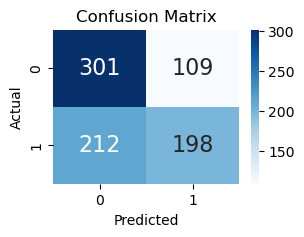

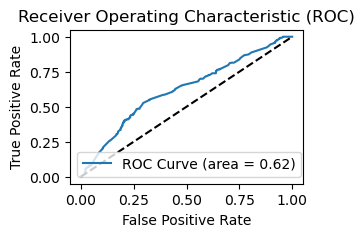

ROC AUC: 0.6379
Accuracy: 0.5861
Recall(most important): 0.5512


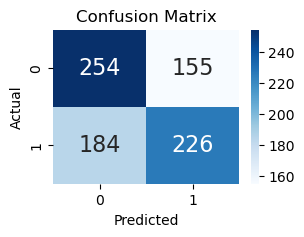

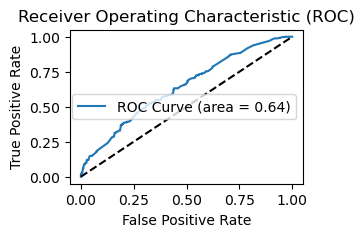

ROC AUC: 0.6627
Accuracy: 0.6154
Recall(most important): 0.5805


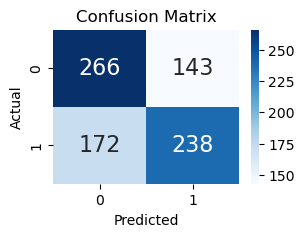

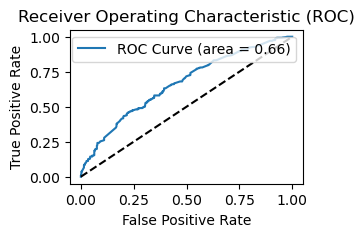

ROC AUC: 0.6531
Accuracy: 0.6178
Recall(most important): 0.6064


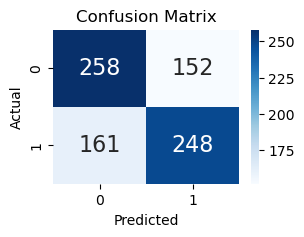

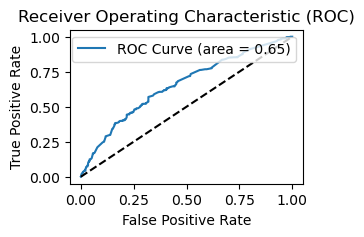

ROC AUC: 0.6830
Accuracy: 0.6264
Recall(most important): 0.5819


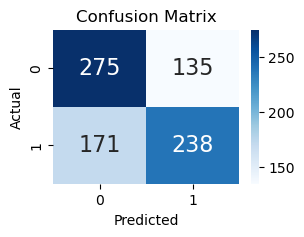

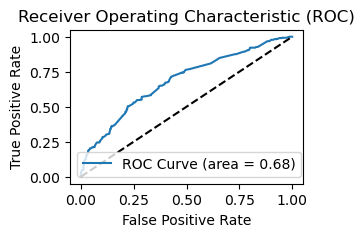

Run 1 average - Accuracy: 0.611, Recall: 0.561, ROC AUC: 0.651
ROC AUC: 0.6602
Accuracy: 0.6110
Recall(most important): 0.5146


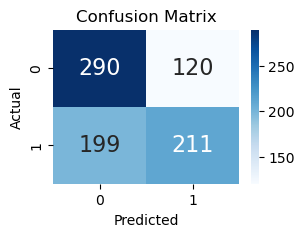

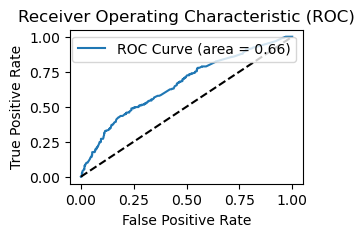

ROC AUC: 0.6940
Accuracy: 0.6569
Recall(most important): 0.6220


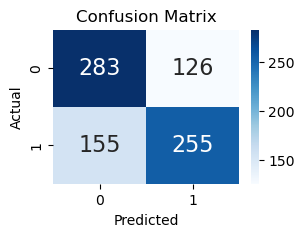

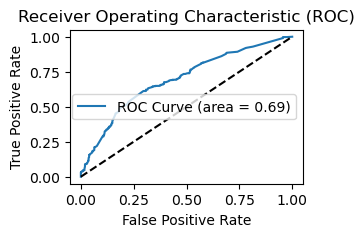

ROC AUC: 0.6844
Accuracy: 0.6227
Recall(most important): 0.5293


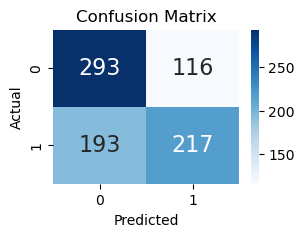

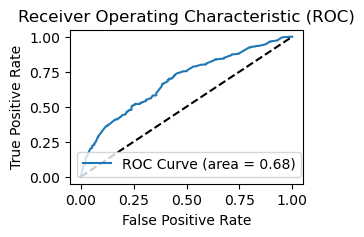

ROC AUC: 0.6391
Accuracy: 0.5995
Recall(most important): 0.5501


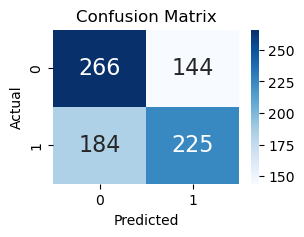

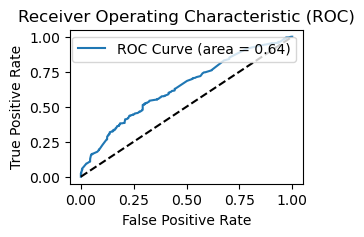

ROC AUC: 0.6828
Accuracy: 0.6410
Recall(most important): 0.5599


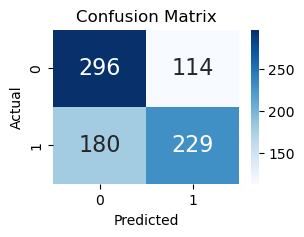

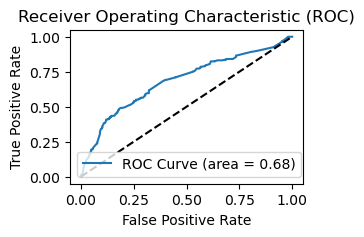

Run 2 average - Accuracy: 0.626, Recall: 0.555, ROC AUC: 0.672
ROC AUC: 0.6856
Accuracy: 0.6415
Recall(most important): 0.5561


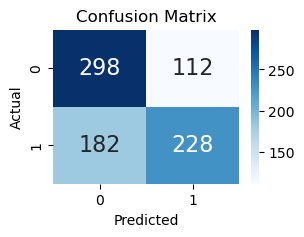

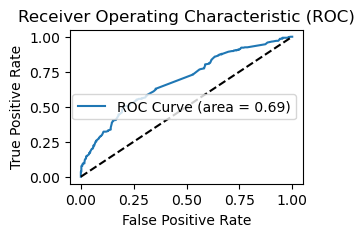

ROC AUC: 0.6438
Accuracy: 0.5934
Recall(most important): 0.4732


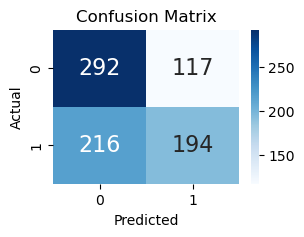

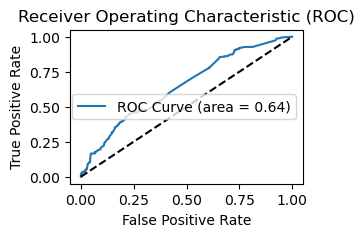

ROC AUC: 0.6388
Accuracy: 0.5983
Recall(most important): 0.4561


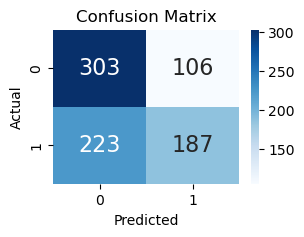

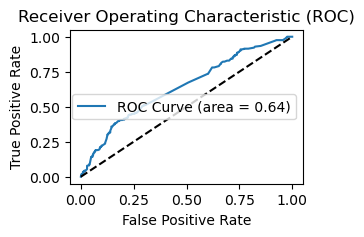

ROC AUC: 0.6706
Accuracy: 0.6178
Recall(most important): 0.4841


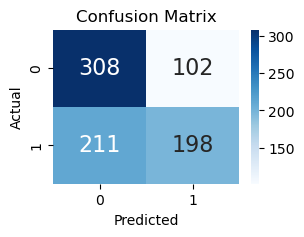

KeyboardInterrupt: 

In [24]:
best_model = run_cv_exps(dfday, n_splits=5, n_runs=5, 
                        C=0.01, penalty='elasticnet', 
                        solver='saga', l1_ratio=0.5)

## changed it to holdout a subset of trainig data for validation after CV

In [35]:
def run_cv_holdout_exps(df, n_splits=5, n_runs=5, holdout_size=0.2, sample_size=4096, **params):
    '''
    Run experiments with both hold-out validation and k-fold cross-validation
    holdout_size: proportion of data to hold out for final testing
    sample_size: number of samples to use (increased from 2048 to ensure enough data)
    '''
    all_cv_results = []
    all_holdout_results = []
    best_model = None
    best_recall = 0
    run = 0
    
    for run in range(n_runs):
        # First split into train+cv and holdout sets
        df_balanced = getregsubset(df, sample_size)
        df_means, df_std = getMeanStd(df_balanced)
        
        # Split into holdout and training sets
        train_df, holdout_df = train_test_split(
            df_balanced, 
            test_size=holdout_size,
            stratify=df_balanced['injury'],
            random_state=run
        )
        
        # Normalize training data
        X_train = train_df.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y_train = train_df['injury']
        X_train = X_train.drop(columns=['injury','Athlete ID', 'date'], errors='ignore')
        
        # Create stratified k-fold for training data
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run)
        
        # Perform k-fold CV on training data
        fold_results = []
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_fold_train, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = train_model(X_fold_train, y_fold_train, **params)
            y_pred = model.predict(X_val)
            results = eval(model, y_val, X_val, y_pred)  # Using non-visual evaluation
            fold_results.append(results)
            
            if results[1] > best_recall and results[0] > 0.65:
                best_model = model
                best_recall = results[1]
        
        # Average CV results for this run
        cv_run_results = np.mean(fold_results, axis=0)
        all_cv_results.append(cv_run_results)
        
        # Now evaluate on holdout set
        X_holdout = holdout_df.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y_holdout = holdout_df['injury']
        X_holdout = X_holdout.drop(columns=['injury','Athlete ID', 'date'], errors='ignore')
        
        # Train final model on all training data
        final_model = train_model(X_train, y_train, **params)
        holdout_pred = final_model.predict(X_holdout)
        print(f"Holdout results for run {run+1}:")
        holdout_results = vis_and_eval(final_model, y_holdout, X_holdout, holdout_pred)
        all_holdout_results.append(holdout_results)
        
        print(f"\nRun {run+1}:")
        print(f"CV - Accuracy: {cv_run_results[0]:.3f}, Recall: {cv_run_results[1]:.3f}, ROC AUC: {cv_run_results[2]:.3f}")
        print(f"Holdout - Accuracy: {holdout_results[0]:.3f}, Recall: {holdout_results[1]:.3f}, ROC AUC: {holdout_results[2]:.3f}")
    
    # Print overall performance
    print("\nOverall CV Performance:")
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_cv_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_cv_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_cv_results]):.3f}")
    
    print("\nOverall Holdout Performance:")
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_holdout_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_holdout_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_holdout_results]):.3f}")
    
    return best_model

ROC AUC: 0.678, Accuracy: 0.622, Recall(most important): 0.562
ROC AUC: 0.639, Accuracy: 0.618, Recall(most important): 0.613
ROC AUC: 0.666, Accuracy: 0.622, Recall(most important): 0.580
ROC AUC: 0.658, Accuracy: 0.623, Recall(most important): 0.582
ROC AUC: 0.676, Accuracy: 0.631, Recall(most important): 0.559
Holdout results for run 1:
ROC AUC: 0.6696
Accuracy: 0.6242
Recall(most important): 0.5678


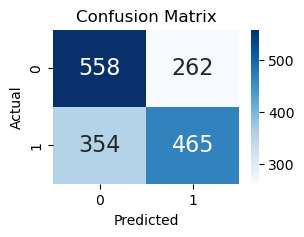

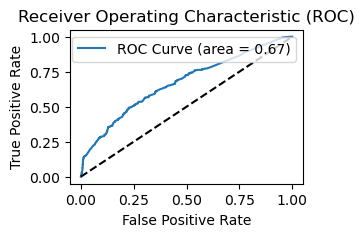


Run 1:
CV - Accuracy: 0.623, Recall: 0.579, ROC AUC: 0.663
Holdout - Accuracy: 0.624, Recall: 0.568, ROC AUC: 0.670


ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [36]:
best_model = run_cv_holdout_exps(dfday, 
                                n_splits=5, 
                                n_runs=5,
                                holdout_size=0.2,
                                sample_size=4096,
                                C=0.01, 
                                penalty='elasticnet', 
                                solver='saga', 
                                l1_ratio=0.5)

### redefine train model for more iters
should run even slower now!

still using above line to run it

In [25]:
def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''
    # model = XGBClassifier()
    # model = GaussianNB()

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

## changed it to track best model based on performance on the holdout set

### Also dropped athlete 55 for causing issues

In [60]:
def run_cv_holdout_exps(df, n_splits=5, n_runs=5, holdout_size=0.2, sample_size=4096, **params):
    '''
    Run experiments with both hold-out validation and k-fold cross-validation
    Saves the model that performs best on the holdout set (high recall with acceptable accuracy)
    '''
    all_cv_results = []
    all_holdout_results = []
    best_model = None
    best_recall = 0
    best_accuracy = 0
    run = 0 
    
    
    
    while run < n_runs:
        # First split into train+cv and holdout sets
        df_balanced = getregsubset(df, sample_size)
        df_means, df_std = getMeanStd(df_balanced)
        
        # Split into holdout and training sets
        train_df, holdout_df = train_test_split(
            df_balanced, 
            test_size=holdout_size,
            stratify=df_balanced['injury'],
            random_state=run
        )
        
        # Normalize training data
        X_train = train_df.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y_train = train_df['injury']
        X_train = X_train.drop(columns=['injury','Athlete ID', 'date'], errors='ignore')
        
        # Normalize holdout data
        X_holdout = holdout_df.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y_holdout = holdout_df['injury']
        X_holdout = X_holdout.drop(columns=['injury','Athlete ID', 'date'], errors='ignore')
        


        # Create stratified k-fold for training data
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run)
        
        # Perform k-fold CV on training data
        fold_results = []
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_fold_train, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = train_model(X_fold_train, y_fold_train, **params)
            y_pred = model.predict(X_val)
            print(f"val for Fold {fold+1} results:")
            results = eval(model, y_val, X_val, y_pred)  # Using non-visual evaluation
            fold_results.append(results)
            
            if results[1] > best_recall and results[0] > 0.6:
                best_model = model
                best_recall = results[1]
                best_accuracy = results[0]
        
        # Average CV results for this run
        cv_run_results = np.mean(fold_results, axis=0)
        all_cv_results.append(cv_run_results)
        
        
        
        # Train final model on all training data
        final_model = train_model(X_train, y_train, **params)
        try:
            holdout_pred = final_model.predict(X_holdout)
            holdout_results = eval(final_model, y_holdout, X_holdout, holdout_pred)
            all_holdout_results.append(holdout_results)
            
            # Track best model based on holdout performance
            print( f' does this model beat previous one?accuracy = {holdout_results[0]:.3f}, recall = {holdout_results[1]:.3f}, roc_auc = {holdout_results[2]:.3f}')
            if (holdout_results[1] > best_recall and  # Better recall
                holdout_results[0] > 0.6):  # Better overall
                best_model = final_model
                best_recall = holdout_results[1]
                best_accuracy = holdout_results[0]
                print(f"\nNew best model found in run {run+1}:")
                print(f"Holdout - Accuracy: {holdout_results[0]:.3f}, Recall: {holdout_results[1]:.3f}, ROC AUC: {holdout_results[2]:.3f}")
        except ValueError as e:
            print ('/n/n/n error/n/n/n')
            print(X_holdout)
            break  
        print(f"\nRun {run+1}:")
        print(f"CV - Accuracy: {cv_run_results[0]:.3f}, Recall: {cv_run_results[1]:.3f}, ROC AUC: {cv_run_results[2]:.3f}")
        print(f"Holdout - Accuracy: {holdout_results[0]:.3f}, Recall: {holdout_results[1]:.3f}, ROC AUC: {holdout_results[2]:.3f}")
        run += 1
    # Print overall performance
    print("\nOverall CV Performance:")
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_cv_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_cv_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_cv_results]):.3f}")
    
    print("\nOverall Holdout Performance:")
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_holdout_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_holdout_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_holdout_results]):.3f}")
    

    # Add information about the best model's performance
    print("\nBest Model Performance (on holdout):")
    print(f"Recall: {best_recall:.3f}")
    print(f"Accuracy: {best_accuracy:.3f}")
    
    return best_model # Also return normalization parameters for future use

In [63]:
dfday_55 = dfday.drop(dfday[dfday['Athlete ID'] == 55].index)
best_model = run_cv_holdout_exps(dfday_55, 
                                             n_splits=5, 
                                             n_runs=5,
                                             holdout_size=0.2,
                                             sample_size=4096,
                                             C=0.01, 
                                             penalty='elasticnet', 
                                             solver='saga', 
                                             l1_ratio=0.5)

# Save model and normalization parameters
with open('../models/mvp2best_logistic_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)


val for Fold 1 results:
ROC AUC: 0.676, Accuracy: 0.621, Recall(most important): 0.544
val for Fold 2 results:
ROC AUC: 0.654, Accuracy: 0.616, Recall(most important): 0.575
val for Fold 3 results:
ROC AUC: 0.685, Accuracy: 0.639, Recall(most important): 0.583
val for Fold 4 results:
ROC AUC: 0.675, Accuracy: 0.631, Recall(most important): 0.583
val for Fold 5 results:
ROC AUC: 0.660, Accuracy: 0.627, Recall(most important): 0.586
ROC AUC: 0.676, Accuracy: 0.620, Recall(most important): 0.579
 does this model beat previous one?accuracy = 0.620, recall = 0.579, roc_auc = 0.676

Run 1:
CV - Accuracy: 0.627, Recall: 0.574, ROC AUC: 0.670
Holdout - Accuracy: 0.620, Recall: 0.579, ROC AUC: 0.676
val for Fold 1 results:
ROC AUC: 0.678, Accuracy: 0.624, Recall(most important): 0.561
val for Fold 2 results:
ROC AUC: 0.650, Accuracy: 0.612, Recall(most important): 0.547
val for Fold 3 results:
ROC AUC: 0.694, Accuracy: 0.617, Recall(most important): 0.627
val for Fold 4 results:
ROC AUC: 0.682,

# Checking for the source of some of the data issues


In [47]:
dfday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42680 entries, 0 to 42679
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Athlete ID                                42680 non-null  int64  
 1   Date                                      42680 non-null  int64  
 2   injury                                    42680 non-null  int64  
 3   Day1 total km                             42680 non-null  float64
 4   Day1 km z3+                               42680 non-null  float64
 5   Day1 km z5                                42680 non-null  float64
 6   Day2-3 nr.sessions                        42680 non-null  float64
 7   Day2-3 total km                           42680 non-null  float64
 8   Day2-3 km z3+                             42680 non-null  float64
 9   Day2-3 km z5                              42680 non-null  float64
 10  Day4-7 nr.sessions                

In [ ]:
def check_data_issues(df):
    """
    Check each column for NaN, inf, and numbers too large for float64
    Print problematic rows and provide a summary
    """
    float64_max = np.finfo(np.float64).max
    float64_min = np.finfo(np.float64).min
    
    print("Checking for data issues...\n")
    
    issues_found = False
    
    # Check each column
    for col in df.columns:
        # Check for NaN
        nan_mask = df[col].isna()
        if nan_mask.any():
            print(f"\nNaN values found in column '{col}':")
            print(df[nan_mask])
            issues_found = True
        
        # Check for inf and extremely large numbers
        # Only check numeric columns
        if np.issubdtype(df[col].dtype, np.number):
            inf_mask = ~np.isfinite(df[col])
            large_num_mask = (df[col] > float64_max/2) | (df[col] < float64_min/2)
            
            if inf_mask.any():
                print(f"\nInfinite values found in column '{col}':")
                print(df[inf_mask])
                issues_found = True
            
            if large_num_mask.any():
                print(f"\nExtremely large values found in column '{col}':")
                print(df[large_num_mask])
                issues_found = True
    
    if not issues_found:
        print("No issues found! All values are within normal ranges.")
    
    # Print summary statistics
    print("\nSummary statistics for numeric columns:")
    print(df.describe())

# Run the check on your DataFrame
check_data_issues(dfday)

Checking for data issues...

No issues found! All values are within normal ranges.

Summary statistics for numeric columns:
         Athlete ID          Date        injury  Day1 total km   Day1 km z3+  \
count  42680.000000  42680.000000  42680.000000   42680.000000  42680.000000   
mean      34.513800   1227.653608      0.013472       7.037254      1.272055   
std       19.023396    807.224150      0.115287       7.457574      2.813510   
min        0.000000      0.000000      0.000000       0.000000      0.000000   
25%       20.000000    435.000000      0.000000       0.000000      0.000000   
50%       34.000000   1254.000000      0.000000       6.000000      0.000000   
75%       50.000000   1915.000000      0.000000      12.000000      0.000000   
max       73.000000   2673.000000      1.000000      55.900000     48.000000   

         Day1 km z5  Day2-3 nr.sessions  Day2-3 total km  Day2-3 km z3+  \
count  42680.000000        42680.000000     42680.000000   42680.000000   
mean 

In [56]:
def run_and_check_for_issues(df, n_splits=5, n_runs=5, holdout_size=0.2, sample_size=4096, **params):
    '''
    Run experiments with both hold-out validation and k-fold cross-validation
    Saves the model that performs best on the holdout set (high recall with acceptable accuracy)
    '''
    all_cv_results = []
    all_holdout_results = []
    best_model = None
    best_recall = 0
    best_accuracy = 0
    run = 0 
    
    
    
    for run in range(n_runs):
        # First split into train+cv and holdout sets
        df_balanced = getregsubset(df, sample_size)
        df_means, df_std = getMeanStd(df_balanced)
        
        # Split into holdout and training sets
        train_df, holdout_df = train_test_split(
            df_balanced, 
            test_size=holdout_size,
            stratify=df_balanced['injury'],
            random_state=run
        )
        
        # Normalize training data
        X_train = train_df.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y_train = train_df['injury']
        X_train = X_train.drop(columns=['injury','Athlete ID', 'date'], errors='ignore')
        
        # Normalize holdout data
        X_holdout = holdout_df.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        y_holdout = holdout_df['injury']
        X_holdout = X_holdout.drop(columns=['injury','Athlete ID', 'date'], errors='ignore')
        print(f"\nChecking data issues in training sets {run}...")
        check_data_issues(X_train)
        print("\nChecking data issues in X holdout set sets...")
        check_data_issues(X_holdout)
        print("\nChecking data issues in y holdout set sets...")
        # check_data_issues(y_holdout)

# drop the columns for athlete 55
dfday.shape
dfday_55 = dfday.drop(dfday[dfday['Athlete ID'] == 55].index)
dfday_55.shape
run_and_check_for_issues(dfday_55)


Checking data issues in training sets 0...
Checking for data issues...

No issues found! All values are within normal ranges.

Summary statistics for numeric columns:
       5day/3W hours alternative training ratio  5day/3W nr. sessions ratio  \
count                               6553.000000                 6553.000000   
mean                                   0.036570                    0.095933   
std                                    1.632082                    0.976289   
min                                   -1.382913                   -4.771719   
25%                                   -0.517016                   -0.371802   
50%                                   -0.307538                    0.081171   
75%                                    0.032649                    0.572459   
max                                  100.000000                    6.263559   

       5day/3W proportion km z3+  5day/3W tot km ratio         ACWR  \
count                6553.000000           6553.0

In [55]:
df_balanced = getregsubset(dfday, 4096)
df_means, df_std = getMeanStd(df_balanced)
df_means.tail(25)

,Date,injury,Day1 total km,Day1 km z3+,Day1 km z5,Day2-3 nr.sessions,Day2-3 total km,Day2-3 km z3+,Day2-3 km z5,Day4-7 nr.sessions,...,Week1 total km z3+,Week1 max km Z3+ one day,Week2 max km one day,Week2 total km z3+,Week2 max km Z3+ one day,5day/3W tot km ratio,5day/3W proportion km z3+,5day/3W nr. sessions ratio,5day/3W hours alternative training ratio,ACWR
Athlete ID,,,,,,,,,,,,,,,,,,,,,
49,1532.473684,0.0,7.247368,1.686842,0.126316,1.210526,9.047368,1.807895,0.000000,2.236842,...,12.671053,10.236842,16.444737,9.244737,6.710526,0.197237,0.789947,0.203947,0.088447,0.787594
50,1724.723684,0.0,13.497368,1.968421,0.652632,2.184211,27.130263,4.588158,1.750000,4.276316,...,14.298684,9.113158,22.873684,13.457895,8.927632,0.235408,1.042461,0.237276,0.005961,0.948498
51,1121.280000,0.0,9.960000,0.000000,0.000000,1.520000,14.240000,0.000000,0.000000,2.880000,...,0.400000,0.400000,17.920000,0.000000,0.000000,0.258520,0.000000,0.251080,0.000000,1.032388
52,1753.152941,0.0,3.049412,0.704706,0.015294,1.694118,6.249412,1.265882,0.007059,3.317647,...,3.923529,2.342353,6.751765,3.728235,2.268235,0.239118,0.710835,0.238741,0.145329,0.966144
53,1237.909091,0.0,6.345455,0.054545,0.054545,1.636364,13.854545,1.109091,1.109091,3.090909,...,5.418182,4.063636,15.663636,7.309091,4.390909,0.269727,0.433364,0.284545,0.000000,1.040111
54,1698.026549,0.0,5.973451,0.797345,0.569912,1.920354,14.499115,2.222124,0.913274,3.495575,...,8.116814,5.602655,12.653097,7.565487,5.238938,0.258566,0.704009,0.252478,0.270354,1.016999
55,1077.000000,0.0,7.925000,3.750000,1.500000,1.500000,17.625000,8.750000,1.500000,3.500000,...,20.475000,12.425000,10.900000,10.050000,5.350000,0.312500,1.063000,0.280750,0.000000,1.211298
56,1785.513514,0.0,4.254054,1.651351,1.435135,1.486486,8.278378,2.475676,2.186486,2.810811,...,12.016216,7.954054,9.981081,9.905405,6.300000,0.216541,0.814622,0.229054,0.047595,0.853186
57,1907.373134,0.0,6.677612,0.911940,0.335821,1.582090,12.722388,1.867164,0.814925,3.059701,...,7.464179,4.386567,15.976119,8.859701,5.697015,0.222642,0.705164,0.231060,0.062254,0.879380


In [58]:
dfday.shape


(42680, 24)

In [ ]:
dfday_55 = dfday.drop(dfday[dfday['Athlete ID'] == 55].index)
dfday_55.shape

(42632, 24)

In [1]:
dfday.head()

NameError: name 'dfday' is not defined